## 1. Setup & Configuration

# HeatSense Phase 1 — 1D-CNN with Enriched Features

**Goal:** Beat the XGBoost baseline using a 1D-CNN optimized for ESP32-S3 deployment.

**Why CNN before LSTM?**
- `Conv1D` ops are natively supported and SIMD-optimized in TFLite Micro on ESP32-S3
- No sequential dependency → deterministic inference latency (~2-5 ms vs 10-20 ms for LSTM)
- Fewer parameters for equivalent receptive field (dilated convolutions)
- Better suited for the dual-core Xtensa LX7 architecture

**Architecture:** Depthwise-separable 1D-CNN + Static Dense branch

**Same enriched features that broke through the CNN V1-V3 ceiling:**
- `time_in_session` (r=0.72), `cumulative_HR` (r=0.77)
- `Perceptual_TS`, `Perceptual_TC` (forward-filled)
- `Activity_Workrest`, slope features
- Weighted MSE for elevated Tcore samples

**XGBoost baseline to beat:**
| Metric | XGBoost |
|---|---|
| MAE | 0.2303 C |
| RMSE | 0.2908 C |
| R2 | 0.4648 |
| Sens@38.5 | 0.419 |
| CV MAE | ~0.23 |

## 2. Load & Clean Data

In [ ]:
import os
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Concatenate, ReLU,
    BatchNormalization, GaussianNoise,
    Conv1D, SeparableConv1D, GlobalAveragePooling1D, Add,
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

print(f"TensorFlow: {tf.__version__}")

from google.colab import drive
drive.mount('/content/drive')

# --- Paths ---
DATA_DIR = '/content/drive/MyDrive/HeatSense'
RAW_DATA_PATH = os.path.join(DATA_DIR, 'sen_ds_raw.xlsx')
DATA_SHEET = 'Data'
OUTPUT_DIR = os.path.join(DATA_DIR, 'output_cnn')
MODEL_DIR = os.path.join(OUTPUT_DIR, 'models')

# --- Reproducibility ---
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# --- Column renames (same as Phase 0) ---
COLUMN_RENAME = {
    'SkinTemp_upper_arm': 'SkinTemp_UpperArm',
    'Environmental_temperature_(chamber_or_cooling_area_outside_chamber)_Temp': 'Env_Temp',
    'Environmental_temperature_(chamber_or_cooling_area_outside_chamber)_Humidity': 'Env_Humidity',
    'InsulatedskinTemp_HR': 'HR',
    'Activity_code': 'Activity_Code',
    'Bodymasskg': 'Body_Mass_Kg',
    'Heightcm': 'Height_Cm',
    'Bodyfat%': 'Body_Fat_Pct',
    'VO2peakmlkgmin': 'VO2Peak',
    'Acclimationstatus': 'Acclimation_Status',
    'Trainingstatus': 'Training_Status',
}

MISSING_SENTINEL = 9999
TARGET = 'Corerectal'

# --- Feature configuration ---
WINDOW_SIZE = 30          # 30-minute lookback
TRAIN_STRIDE = 1          # Dense stride for CNN (more training data)
EVAL_STRIDE = 5           # Non-overlapping eval

# Dynamic features fed as time-series to Conv1D
DYNAMIC_FEATURES = ['HR', 'SkinTemp_UpperArm', 'Env_Temp',
                     'time_in_session', 'cumulative_HR',
                     'HR_slope_5m', 'SkinTemp_slope_5m']
PERCEPTUAL_FEATURES = ['Perceptual_TS', 'Perceptual_TC']
ACTIVITY_FEATURES = ['Activity_Workrest']

# Static features (participant-level, fed via dense branch)
STATIC_FEATURES = ['Age', 'Sex_Encoded', 'BMI', 'VO2Peak',
                    'Acclimation_Encoded', 'Training_Encoded']

# --- Model hyperparameters ---
FILTERS = [32, 48, 64]         # Conv1D filter progression
KERNEL_SIZE = 5                # Receptive field per layer
DENSE_UNITS = 24               # Merge branch
DROPOUT_RATE = 0.25
L2_REG = 1e-4
NOISE_STDDEV = 0.02
LEARNING_RATE = 1e-3

# Training
MAX_EPOCHS = 200
BATCH_SIZE = 64
PATIENCE = 25

# Weighted loss
ELEVATED_WEIGHT_ALPHA = 5.0
ELEVATED_WEIGHT_THRESHOLD = 37.5

# Split
TEST_SIZE = 0.30
VAL_FRACTION = 0.50

os.makedirs(MODEL_DIR, exist_ok=True)
print("Setup complete.")
print(f"  Data: {RAW_DATA_PATH}")
print(f"  Output: {OUTPUT_DIR}")
print(f"  Window: {WINDOW_SIZE} min, Dynamic: {len(DYNAMIC_FEATURES)} feats")

TensorFlow: 2.19.0
Mounted at /content/drive
Setup complete.
  Data: /content/drive/MyDrive/HeatSense/sen_ds_raw.xlsx
  Output: /content/drive/MyDrive/HeatSense/output_cnn
  Window: 30 min, Dynamic: 7 feats


In [ ]:
# ============================================================
# LOAD RAW DATA (identical to Phase 0 for reproducibility)
# ============================================================

def flatten_multiindex(df):
    new_cols = []
    for col in df.columns:
        lvl0 = str(col[0]).strip()
        lvl1 = str(col[1]).strip()
        if 'Unnamed' in lvl0:
            new_cols.append(lvl1)
        elif lvl0 == lvl1:
            new_cols.append(lvl0)
        else:
            new_cols.append(f"{lvl0}_{lvl1}")
    df.columns = new_cols
    df.columns = [c.split('_Unnamed')[0].strip().replace(' ', '_') for c in df.columns]
    return df

print("Loading raw data...")
df = pd.read_excel(RAW_DATA_PATH, sheet_name=DATA_SHEET, header=[0, 1])
df = flatten_multiindex(df)
df.rename(columns=COLUMN_RENAME, inplace=True)
df.replace([MISSING_SENTINEL, float(MISSING_SENTINEL)], np.nan, inplace=True)

# Session identification
df['Time_Sec'] = pd.to_timedelta(df['Time'].astype(str), errors='coerce').dt.total_seconds()
df['Session_ID'] = (
    (df['Participant'] != df['Participant'].shift(1)) |
    (df['Time_Sec'] < df['Time_Sec'].shift(1))
).cumsum()

# Forward-fill HR within sessions (handles P1-P18 5-min sampling)
before_nan = df['HR'].isna().sum()
for sid in df['Session_ID'].unique():
    mask = df['Session_ID'] == sid
    df.loc[mask, 'HR'] = df.loc[mask, 'HR'].ffill(limit=5)
after_nan = df['HR'].isna().sum()
print(f"  HR forward-fill: {before_nan - after_nan} NaN resolved, {after_nan} remain")

# Forward-fill perceptual inputs within sessions
perceptual_cols = ['Perceptual_TS', 'Perceptual_TC']
actual_perceptual = {}
for target_name in perceptual_cols:
    matches = [c for c in df.columns if target_name.replace('Perceptual_', '') in c and 'Perceptual' in c]
    if matches:
        actual_perceptual[target_name] = matches[0]

print(f"  Perceptual columns found: {actual_perceptual}")

for nice_name, real_name in actual_perceptual.items():
    before_p = df[real_name].isna().sum()
    for sid in df['Session_ID'].unique():
        mask = df['Session_ID'] == sid
        df.loc[mask, real_name] = df.loc[mask, real_name].ffill()
    after_p = df[real_name].isna().sum()
    if real_name != nice_name:
        df.rename(columns={real_name: nice_name}, inplace=True)
    print(f"  {nice_name}: ffill {before_p - after_p} NaN -> {after_p} remain "
          f"({(1 - after_p/len(df))*100:.1f}% coverage)")

# Activity work/rest
workrest_candidates = [c for c in df.columns if 'workrest' in c.lower() or 'work_rest' in c.lower()]
if workrest_candidates:
    df.rename(columns={workrest_candidates[0]: 'Activity_Workrest'}, inplace=True)
    print(f"  Activity_Workrest: {df['Activity_Workrest'].notna().sum()}/{len(df)} rows")
else:
    for c in df.columns:
        if 'Activity' in c and 'workrest' in c.lower():
            df.rename(columns={c: 'Activity_Workrest'}, inplace=True)
            break
    if 'Activity_Workrest' not in df.columns:
        print("  WARNING: Activity_Workrest column not found!")
        act_cols = [c for c in df.columns if 'ctiv' in c.lower()]
        print(f"  Activity-related columns: {act_cols}")

# Encode features
df['Sex_Encoded'] = df['Sex'].map({1: 1, 2: 0, '1': 1, '2': 0}).fillna(1).astype('float32')
height_m = (df['Height_Cm'] / 100).replace(0, np.nan)
df['BMI'] = (df['Body_Mass_Kg'] / (height_m ** 2)).astype('float32')
df['Acclimation_Encoded'] = df['Acclimation_Status'].astype('float32')
df['Training_Encoded'] = df['Training_Status'].map({1: 1, 2: 0}).fillna(0).astype('float32')

# Drop rows with no target
before = len(df)
df = df.dropna(subset=[TARGET]).copy()
print(f"  Dropped {before - len(df)} rows with missing {TARGET}")

# Drop rows where BOTH HR and SkinTemp are NaN
before = len(df)
df = df.dropna(subset=['HR', 'SkinTemp_UpperArm'], how='all').copy()
if before - len(df) > 0:
    print(f"  Dropped {before - len(df)} ghost rows")

print(f"\n  Final: {len(df)} rows, {df['Session_ID'].nunique()} sessions, "
      f"{df['Participant'].nunique()} participants")
print(f"  Target: mean={df[TARGET].mean():.2f}, std={df[TARGET].std():.2f}, "
      f"range=[{df[TARGET].min():.2f}, {df[TARGET].max():.2f}]")

Loading raw data...
  HR forward-fill: 5268 NaN resolved, 43 remain
  Perceptual columns found: {'Perceptual_TS': 'Perceptual_TS', 'Perceptual_TC': 'Perceptual_TC'}
  Perceptual_TS: ffill 15380 NaN -> 10 remain (99.9% coverage)
  Perceptual_TC: ffill 15380 NaN -> 10 remain (99.9% coverage)
  Activity_Workrest: 17264/17264 rows
  Dropped 68 rows with missing Corerectal

  Final: 17196 rows, 155 sessions, 40 participants
  Target: mean=37.87, std=0.56, range=[35.96, 39.53]


## 3. Feature Engineering

In [ ]:
# ============================================================
# FEATURE ENGINEERING (per-session, identical to Phase 0)
# ============================================================

print("Engineering features per session...")
result_parts = []
for sid, session in df.groupby('Session_ID'):
    session = session.sort_values('Time_Sec').copy()

    # Time in session (minutes)
    session['time_in_session'] = (session['Time_Sec'] - session['Time_Sec'].iloc[0]) / 60.0

    # Cumulative HR (metabolic heat storage proxy)
    resting_hr = 70.0
    hr_filled = session['HR'].fillna(resting_hr)
    session['cumulative_HR'] = (hr_filled - resting_hr).clip(lower=0).cumsum()

    # Slopes (rate of change over last 5 minutes)
    session['HR_slope_5m'] = session['HR'].diff(periods=5).fillna(0)
    session['SkinTemp_slope_5m'] = session['SkinTemp_UpperArm'].diff(periods=5).fillna(0)

    # Activity work/rest (ensure numeric)
    if 'Activity_Workrest' in session.columns:
        session['Activity_Workrest'] = session['Activity_Workrest'].fillna(1).astype('float32')

    result_parts.append(session)

df = pd.concat(result_parts).sort_index()

# Show new features
new_feats = ['time_in_session', 'cumulative_HR', 'HR_slope_5m', 'SkinTemp_slope_5m']
print(f"\nNew features added: {new_feats}")
for f in new_feats:
    print(f"  {f}: mean={df[f].mean():.2f}, std={df[f].std():.2f}, "
          f"NaN={df[f].isna().sum()}")

# Correlation check
print(f"\n--- Feature Correlations with {TARGET} ---")
corr_features = ['time_in_session', 'cumulative_HR', 'HR', 'SkinTemp_UpperArm',
                  'HR_slope_5m', 'SkinTemp_slope_5m', 'Env_Temp']
if 'Perceptual_TS' in df.columns:
    corr_features.append('Perceptual_TS')
if 'Perceptual_TC' in df.columns:
    corr_features.append('Perceptual_TC')
if 'Activity_Workrest' in df.columns:
    corr_features.append('Activity_Workrest')

for f in corr_features:
    valid = df[[f, TARGET]].dropna()
    if len(valid) > 10:
        r = valid[f].corr(valid[TARGET])
        print(f"  {f:25s}: r = {r:+.4f}  (n={len(valid)})")

Engineering features per session...

New features added: ['time_in_session', 'cumulative_HR', 'HR_slope_5m', 'SkinTemp_slope_5m']
  time_in_session: mean=56.92, std=34.33, NaN=0
  cumulative_HR: mean=2737.30, std=2144.43, NaN=0
  HR_slope_5m: mean=3.62, std=15.83, NaN=0
  SkinTemp_slope_5m: mean=0.17, std=0.57, NaN=0

--- Feature Correlations with Corerectal ---
  time_in_session          : r = +0.7169  (n=17196)
  cumulative_HR            : r = +0.7664  (n=17196)
  HR                       : r = +0.5512  (n=17153)
  SkinTemp_UpperArm        : r = +0.4895  (n=17092)
  HR_slope_5m              : r = -0.2686  (n=17196)
  SkinTemp_slope_5m        : r = -0.3579  (n=17196)
  Env_Temp                 : r = -0.1493  (n=16960)
  Perceptual_TS            : r = +0.3402  (n=17186)
  Perceptual_TC            : r = +0.3212  (n=17186)
  Activity_Workrest        : r = -0.0330  (n=17196)


## 4. Split, Impute, Scale, Window

Leak-proof pipeline: split by participant **first**, then impute/scale using train stats only, then create windows.

In [ ]:
# ============================================================
# SPLIT BY PARTICIPANT -> IMPUTE -> SCALE -> WINDOW
# ============================================================

# --- 1. Split by participant (stratified by max Tcore >= 39.0) ---
part_max = df.groupby('Participant')[TARGET].max()
high_tcore = (part_max >= 39.0).astype(int)
participants = high_tcore.index.values
labels = high_tcore.values

train_parts, temp_parts, _, temp_labels = train_test_split(
    participants, labels, test_size=TEST_SIZE,
    random_state=RANDOM_SEED, stratify=labels
)
val_parts, test_parts = train_test_split(
    temp_parts, test_size=VAL_FRACTION,
    random_state=RANDOM_SEED, stratify=temp_labels
)

print(f"Participant split:")
print(f"  Train: {len(train_parts)} participants: {sorted(train_parts)}")
print(f"  Val:   {len(val_parts)} participants: {sorted(val_parts)}")
print(f"  Test:  {len(test_parts)} participants: {sorted(test_parts)}")

df_train = df[df['Participant'].isin(train_parts)].copy()
df_val = df[df['Participant'].isin(val_parts)].copy()
df_test = df[df['Participant'].isin(test_parts)].copy()

# --- 2. Determine all dynamic columns for the CNN ---
ALL_DYNAMIC = DYNAMIC_FEATURES.copy()
for col in PERCEPTUAL_FEATURES:
    if col in df.columns:
        ALL_DYNAMIC.append(col)
for col in ACTIVITY_FEATURES:
    if col in df.columns:
        ALL_DYNAMIC.append(col)

# Check which static features are available
AVAILABLE_STATIC = [c for c in STATIC_FEATURES if c in df.columns]

print(f"\n  Dynamic features ({len(ALL_DYNAMIC)}): {ALL_DYNAMIC}")
print(f"  Static features ({len(AVAILABLE_STATIC)}): {AVAILABLE_STATIC}")

# --- 3. Impute NaN using TRAINING medians ---
train_medians_dyn = {}
for col in ALL_DYNAMIC:
    median = df_train[col].median()
    train_medians_dyn[col] = median
    df_train[col] = df_train[col].fillna(median)
    df_val[col] = df_val[col].fillna(median)
    df_test[col] = df_test[col].fillna(median)

train_medians_stat = {}
for col in AVAILABLE_STATIC:
    median = df_train[col].median()
    train_medians_stat[col] = median
    df_train[col] = df_train[col].fillna(median)
    df_val[col] = df_val[col].fillna(median)
    df_test[col] = df_test[col].fillna(median)

print(f"\n  NaN imputed with training medians")

# --- 4. Scale dynamic features (fit on train only) ---
dyn_scaler = StandardScaler()
df_train[ALL_DYNAMIC] = dyn_scaler.fit_transform(df_train[ALL_DYNAMIC].values)
df_val[ALL_DYNAMIC] = dyn_scaler.transform(df_val[ALL_DYNAMIC].values)
df_test[ALL_DYNAMIC] = dyn_scaler.transform(df_test[ALL_DYNAMIC].values)

stat_scaler = StandardScaler()
df_train[AVAILABLE_STATIC] = stat_scaler.fit_transform(df_train[AVAILABLE_STATIC].values)
df_val[AVAILABLE_STATIC] = stat_scaler.transform(df_val[AVAILABLE_STATIC].values)
df_test[AVAILABLE_STATIC] = stat_scaler.transform(df_test[AVAILABLE_STATIC].values)

print(f"  Scalers fit on training data")

# --- 5. Create sliding windows ---
def create_windows(df_split, stride, window_size=WINDOW_SIZE):
    """Create (dynamic_window, static_vector, target) tuples."""
    X_dyn, X_stat, Y = [], [], []
    for sid, session in df_split.groupby('Session_ID'):
        session = session.sort_values('Time_Sec')
        if len(session) < window_size:
            continue

        dyn_arr = session[ALL_DYNAMIC].values.astype(np.float32)
        stat_arr = session[AVAILABLE_STATIC].iloc[0].values.astype(np.float32)
        targets = session[TARGET].values.astype(np.float32)

        for i in range(0, len(session) - window_size + 1, stride):
            X_dyn.append(dyn_arr[i:i + window_size])
            X_stat.append(stat_arr)
            Y.append(targets[i + window_size - 1])

    return np.array(X_dyn), np.array(X_stat), np.array(Y)

print(f"\nExtracting windows...")
X_tr_d, X_tr_s, y_tr = create_windows(df_train, stride=TRAIN_STRIDE)
X_va_d, X_va_s, y_va = create_windows(df_val, stride=EVAL_STRIDE)
X_te_d, X_te_s, y_te = create_windows(df_test, stride=EVAL_STRIDE)

print(f"  Train: {X_tr_d.shape[0]} windows, dyn={X_tr_d.shape}, stat={X_tr_s.shape}")
print(f"  Val:   {X_va_d.shape[0]} windows, dyn={X_va_d.shape}, stat={X_va_s.shape}")
print(f"  Test:  {X_te_d.shape[0]} windows, dyn={X_te_d.shape}, stat={X_te_s.shape}")

# Integrity check
for name, xd, xs, y in [('Train', X_tr_d, X_tr_s, y_tr),
                          ('Val', X_va_d, X_va_s, y_va),
                          ('Test', X_te_d, X_te_s, y_te)]:
    assert not np.isnan(xd).any(), f"NaN in {name} dynamic!"
    assert not np.isnan(xs).any(), f"NaN in {name} static!"
    assert not np.isnan(y).any(), f"NaN in {name} targets!"
    print(f"  {name}: OK — target range [{y.min():.2f}, {y.max():.2f}]")

# Target distribution
print(f"\n--- Target Distribution ---")
for name, y in [('Train', y_tr), ('Val', y_va), ('Test', y_te)]:
    print(f"  {name}: mean={y.mean():.2f}, std={y.std():.2f}, "
          f">38.5: {(y>=38.5).sum()} ({(y>=38.5).mean()*100:.1f}%), "
          f">39.0: {(y>=39.0).sum()} ({(y>=39.0).mean()*100:.1f}%)")

# Save scalers
scaler_data = {
    'dynamic': dyn_scaler,
    'static': stat_scaler,
    'dynamic_features': ALL_DYNAMIC,
    'static_features': AVAILABLE_STATIC,
    'train_medians_dyn': train_medians_dyn,
    'train_medians_stat': train_medians_stat,
}
scaler_path = os.path.join(MODEL_DIR, 'scalers_cnn.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler_data, f)
print(f"\n  Scalers saved to {scaler_path}")

Participant split:
  Train: 28 participants: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(17), np.int64(18), np.int64(29), np.int64(31), np.int64(32), np.int64(33), np.int64(35), np.int64(36), np.int64(38), np.int64(39), np.int64(40), np.int64(42), np.int64(45), np.int64(47), np.int64(48)]
  Val:   6 participants: [np.int64(9), np.int64(16), np.int64(30), np.int64(34), np.int64(41), np.int64(43)]
  Test:  6 participants: [np.int64(8), np.int64(37), np.int64(44), np.int64(46), np.int64(49), np.int64(50)]

  Dynamic features (10): ['HR', 'SkinTemp_UpperArm', 'Env_Temp', 'time_in_session', 'cumulative_HR', 'HR_slope_5m', 'SkinTemp_slope_5m', 'Perceptual_TS', 'Perceptual_TC', 'Activity_Workrest']
  Static features (6): ['Age', 'Sex_Encoded', 'BMI', 'VO2Peak', 'Acclimation_Encoded', 'Training_Encoded']

  NaN imputed with training medians
  Scalers fit 

## 5. Build 1D-CNN Model

**Architecture rationale for ESP32-S3:**
- **SeparableConv1D** (depthwise-separable): ~8x fewer multiply-accumulate ops than standard Conv1D
- **3 conv blocks** with increasing filters (32→48→64) capture short/medium/long temporal patterns
- **GlobalAveragePooling1D**: no flatten → smaller FC layer, acts as regularizer
- **Residual skip** from first block to help gradient flow with only 3 blocks
- **Static branch** concatenated after pooling (participant physiology context)
- Total params target: **< 15K** (fits comfortably in ESP32-S3 SRAM)

In [ ]:
# ============================================================
# MODEL: 1D-CNN with depthwise-separable convolutions
# ============================================================

def build_cnn_model(window_size, n_dynamic, n_static):
    """Build a TinyML-friendly 1D-CNN for Tcore regression."""
    reg = l2(L2_REG)

    # --- Dynamic branch: temporal convolutions ---
    input_dyn = Input(shape=(window_size, n_dynamic), name='dynamic_input')
    x = GaussianNoise(NOISE_STDDEV)(input_dyn)

    # Block 1: Standard Conv1D (first layer needs to mix channels)
    x = Conv1D(FILTERS[0], KERNEL_SIZE, padding='causal',
               kernel_regularizer=reg, use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Dropout(DROPOUT_RATE)(x)

    # Save for residual (project to match final filter count)
    skip = Conv1D(FILTERS[2], 1, padding='same', use_bias=False)(x)

    # Block 2: SeparableConv1D (efficient)
    x = SeparableConv1D(FILTERS[1], KERNEL_SIZE, padding='same',
                         depthwise_regularizer=reg, pointwise_regularizer=reg,
                         use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Dropout(DROPOUT_RATE)(x)

    # Block 3: SeparableConv1D
    x = SeparableConv1D(FILTERS[2], KERNEL_SIZE, padding='same',
                         depthwise_regularizer=reg, pointwise_regularizer=reg,
                         use_bias=False)(x)
    x = BatchNormalization()(x)

    # Residual addition
    x = Add()([x, skip])
    x = ReLU()(x)
    x = Dropout(DROPOUT_RATE)(x)

    # Global pooling (no flatten needed, acts as regularizer)
    x = GlobalAveragePooling1D()(x)

    # --- Static branch: participant features ---
    input_stat = Input(shape=(n_static,), name='static_input')
    s = Dense(8, kernel_regularizer=reg)(input_stat)
    s = ReLU()(s)
    s = Dropout(DROPOUT_RATE)(s)

    # --- Merge ---
    merged = Concatenate()([x, s])
    merged = Dense(DENSE_UNITS, kernel_regularizer=reg)(merged)
    merged = ReLU()(merged)
    merged = Dropout(DROPOUT_RATE)(merged)

    output = Dense(1, name='tcore_output')(merged)

    model = Model(inputs=[input_dyn, input_stat], outputs=output, name='HeatSense_CNN')
    return model

# Build
model = build_cnn_model(
    window_size=X_tr_d.shape[1],
    n_dynamic=X_tr_d.shape[2],
    n_static=X_tr_s.shape[1],
)

model.summary()

# Count parameters
total_params = model.count_params()
trainable_params = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f"\n  Total params: {total_params:,}")
print(f"  Trainable params: {trainable_params:,}")
print(f"  Estimated model size (float32): {total_params * 4 / 1024:.1f} KB")
print(f"  Estimated model size (int8):    {total_params / 1024:.1f} KB")

Model: "HeatSense_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dynamic_input       │ (None, 30, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_2    │ (None, 30, 10)    │          0 │ dynamic_input[0]… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 30, 32)    │      1,600 │ gaussian_noise_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 32)    │        128 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 30, 32)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 30, 32)    │          0 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d_2  │ (None, 30, 48)    │      1,696 │ dropout_2[0][0]   │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 48)    │        192 │ separable_conv1d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 30, 48)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 30, 48)    │          0 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d_3  │ (None, 30, 64)    │      3,312 │ dropout_3[0][0]   │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 64)    │        256 │ separable_conv1d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 30, 64)    │      2,048 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 30, 64)    │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │         56 │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 30, 64)    │          0 │ re_lu_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_5 (ReLU)      │ (None, 8)         │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ dropout_4[0][0]   │
│ (GlobalAveragePool… │                   │            │                 

 Total params: 11,065 (43.22 KB)

 Trainable params: 10,777 (42.10 KB)

 Non-trainable params: 288 (1.12 KB)


  Total params: 11,065
  Trainable params: 10,777
  Estimated model size (float32): 43.2 KB
  Estimated model size (int8):    10.8 KB


## 6. Train with Weighted Loss

Target: mean=38.1247, std=0.4481
Weights: min=1.00, max=21.60, mean=3.94

Training for up to 200 epochs, batch_size=64...
Epoch 1/200
142/142 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 1.8124 - mae: 0.5837 - val_loss: 0.5783 - val_mae: 0.6369 - learning_rate: 0.0010
Epoch 2/200
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 1.2176 - mae: 0.4725 - val_loss: 0.3996 - val_mae: 0.5182 - learning_rate: 0.0010
Epoch 3/200
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 1.0471 - mae: 0.4408 - val_loss: 0.3247 - val_mae: 0.4437 - learning_rate: 0.0010
Epoch 4/200
142/142 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.9895 - mae: 0.4218 - val_loss: 0.3052 - val_mae: 0.4297 - learning_rate: 0.0010
Epoch 5/200
142/142 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.9260 - mae: 0.4049 - val_loss: 0.2975 - val_mae: 0.4179 - learning_rate: 0.0010
Epoch 6/200
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.9067 - mae: 0.3961 - val_loss: 0.3351 - val_mae: 0.4421 - learning_rate: 0.0010
Epoch 7/200
1

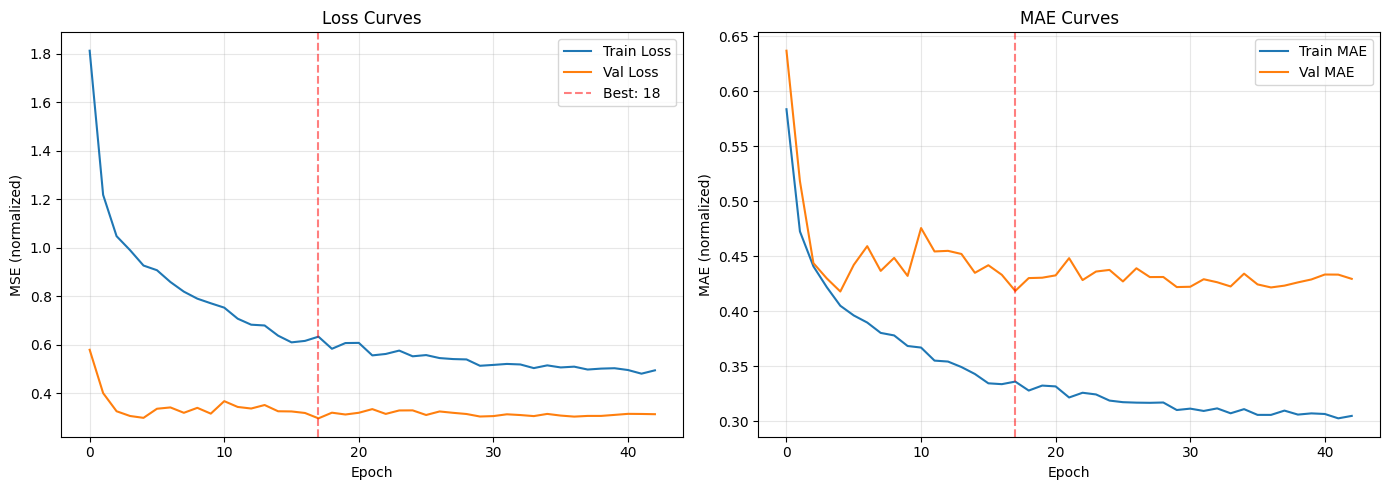

In [ ]:
# ============================================================
# TRAINING
# ============================================================

# Target normalization
y_mean = y_tr.mean()
y_std = y_tr.std()
y_train_norm = (y_tr - y_mean) / y_std
y_val_norm = (y_va - y_mean) / y_std
print(f"Target: mean={y_mean:.4f}, std={y_std:.4f}")

# Sample weights: quadratic penalty for elevated Tcore
sample_weights = 1.0 + ELEVATED_WEIGHT_ALPHA * np.maximum(0, y_tr - ELEVATED_WEIGHT_THRESHOLD) ** 2
print(f"Weights: min={sample_weights.min():.2f}, max={sample_weights.max():.2f}, "
      f"mean={sample_weights.mean():.2f}")

# Compile
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mse',
    metrics=['mae'],
)

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=PATIENCE,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=10,
        min_lr=1e-6, verbose=1
    ),
]

print(f"\nTraining for up to {MAX_EPOCHS} epochs, batch_size={BATCH_SIZE}...")
history = model.fit(
    [X_tr_d, X_tr_s], y_train_norm,
    validation_data=([X_va_d, X_va_s], y_val_norm),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    sample_weight=sample_weights,
    callbacks=callbacks,
    verbose=1,
)

best_epoch = np.argmin(history.history['val_loss']) + 1
print(f"\nBest epoch: {best_epoch}")
print(f"Best val_loss (MSE, normalized): {min(history.history['val_loss']):.6f}")

# Learning curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5, label=f'Best: {best_epoch}')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE (normalized)')
ax1.set_title('Loss Curves'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history.history['mae'], label='Train MAE')
ax2.plot(history.history['val_mae'], label='Val MAE')
ax2.axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('MAE (normalized)')
ax2.set_title('MAE Curves'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Test Evaluation

In [ ]:
# ============================================================
# TEST SET EVALUATION
# ============================================================

y_pred_norm = model.predict([X_te_d, X_te_s], verbose=0).ravel()
y_pred = y_pred_norm * y_std + y_mean  # de-normalize

# --- Regression ---
mae = mean_absolute_error(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))
r2 = r2_score(y_te, y_pred)
print(f"--- Test Regression ---")
print(f"  MAE:  {mae:.4f} C")
print(f"  RMSE: {rmse:.4f} C")
print(f"  R2:   {r2:.4f}")

# --- Threshold Classification ---
print(f"\n--- Threshold-Based Classification ---")
thresh_results = {}
for t in [38.0, 38.5, 39.0]:
    actual_pos = y_te >= t
    pred_pos = y_pred >= t
    tp = np.sum(actual_pos & pred_pos)
    fp = np.sum(~actual_pos & pred_pos)
    fn = np.sum(actual_pos & ~pred_pos)
    tn = np.sum(~actual_pos & ~pred_pos)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
    print(f"\n  Threshold: {t:.1f} C")
    print(f"    Sensitivity: {sensitivity:.3f} | Specificity: {specificity:.3f}")
    print(f"    PPV: {ppv:.3f} | F1: {f1:.3f}")
    print(f"    TP={tp}, FP={fp}, FN={fn}, TN={tn}")
    thresh_results[t] = {
        'sensitivity': sensitivity, 'specificity': specificity,
        'ppv': ppv, 'f1': f1,
    }

# --- False Alarm Rate ---
for threshold in [38.5, 39.0]:
    actual_safe = y_te < threshold
    pred_alarm = y_pred >= threshold
    false_alarms = np.sum(actual_safe & pred_alarm)
    safe_hours = np.sum(actual_safe) / 60
    rate = false_alarms / safe_hours if safe_hours > 0 else 0
    print(f"\n--- False Alarm Rate (threshold={threshold} C) ---")
    print(f"  False alarms: {false_alarms}, Safe hours: {safe_hours:.1f}")
    print(f"  Rate: {rate:.2f} per safe-hour")

--- Test Regression ---
  MAE:  0.1783 C
  RMSE: 0.2209 C
  R2:   0.6911

--- Threshold-Based Classification ---

  Threshold: 38.0 C
    Sensitivity: 0.829 | Specificity: 0.835
    PPV: 0.860 | F1: 0.844
    TP=141, FP=23, FN=29, TN=116

  Threshold: 38.5 C
    Sensitivity: 0.512 | Specificity: 0.962
    PPV: 0.688 | F1: 0.587
    TP=22, FP=10, FN=21, TN=256

  Threshold: 39.0 C
    Sensitivity: 0.200 | Specificity: 1.000
    PPV: 1.000 | F1: 0.333
    TP=2, FP=0, FN=8, TN=299

--- False Alarm Rate (threshold=38.5 C) ---
  False alarms: 10, Safe hours: 4.4
  Rate: 2.26 per safe-hour

--- False Alarm Rate (threshold=39.0 C) ---
  False alarms: 0, Safe hours: 5.0
  Rate: 0.00 per safe-hour


## 8. Plots

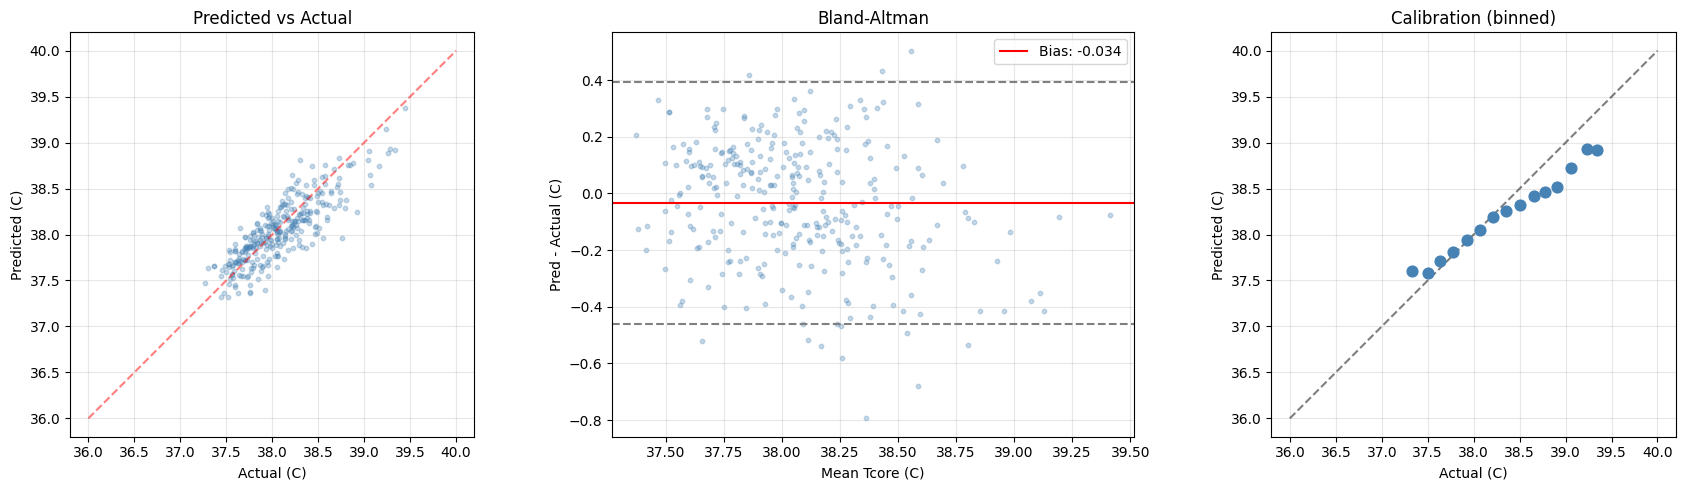


Bland-Altman: Bias=-0.0342, LoA=[-0.4620, 0.3935]


In [ ]:
# ============================================================
# PLOTS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter
ax = axes[0]
ax.scatter(y_te, y_pred, alpha=0.3, s=10, c='steelblue')
ax.plot([36, 40], [36, 40], 'r--', alpha=0.5)
ax.set_xlabel('Actual (C)'); ax.set_ylabel('Predicted (C)')
ax.set_title('Predicted vs Actual'); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

# Bland-Altman
ax = axes[1]
mean_vals = (y_te + y_pred) / 2
diff = y_pred - y_te
mean_diff = np.mean(diff)
std_diff = np.std(diff)
ax.scatter(mean_vals, diff, alpha=0.3, s=10, c='steelblue')
ax.axhline(mean_diff, color='red', linestyle='-', label=f'Bias: {mean_diff:.3f}')
ax.axhline(mean_diff + 1.96 * std_diff, color='gray', linestyle='--')
ax.axhline(mean_diff - 1.96 * std_diff, color='gray', linestyle='--')
ax.set_xlabel('Mean Tcore (C)'); ax.set_ylabel('Pred - Actual (C)')
ax.set_title('Bland-Altman'); ax.legend(); ax.grid(True, alpha=0.3)

# Calibration
ax = axes[2]
bins = np.linspace(y_te.min(), y_te.max(), 16)
bin_actual, bin_pred = [], []
for i in range(len(bins) - 1):
    mask = (y_te >= bins[i]) & (y_te < bins[i + 1])
    if mask.sum() > 0:
        bin_actual.append(y_te[mask].mean())
        bin_pred.append(y_pred[mask].mean())
ax.plot([36, 40], [36, 40], 'k--', alpha=0.5)
ax.scatter(bin_actual, bin_pred, s=60, c='steelblue', zorder=5)
ax.set_xlabel('Actual (C)'); ax.set_ylabel('Predicted (C)')
ax.set_title('Calibration (binned)'); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBland-Altman: Bias={mean_diff:.4f}, "
      f"LoA=[{mean_diff - 1.96*std_diff:.4f}, {mean_diff + 1.96*std_diff:.4f}]")

## 9. Per-Participant MAE

In [ ]:
# ============================================================
# PER-PARTICIPANT MAE
# ============================================================

print("--- Per-Participant MAE (Test Set) ---")
pp_results = {}
for pid, pdata in df_test.groupby('Participant'):
    y_true_list, y_pred_list = [], []
    for sid, session in pdata.groupby('Session_ID'):
        session = session.sort_values('Time_Sec')
        if len(session) < WINDOW_SIZE:
            continue
        dyn_vals = session[ALL_DYNAMIC].values.astype(np.float32)
        stat_vals = session[AVAILABLE_STATIC].iloc[0].values.astype(np.float32)
        targets = session[TARGET].values.astype(np.float32)

        for i in range(0, len(session) - WINDOW_SIZE + 1, EVAL_STRIDE):
            xd = dyn_vals[i:i + WINDOW_SIZE][np.newaxis]
            xs = stat_vals[np.newaxis]
            pred_norm = model.predict([xd, xs], verbose=0).ravel()[0]
            pred = pred_norm * y_std + y_mean
            y_true_list.append(targets[i + WINDOW_SIZE - 1])
            y_pred_list.append(pred)

    if y_true_list:
        y_true_arr = np.array(y_true_list)
        y_pred_arr = np.array(y_pred_list)
        p_mae = mean_absolute_error(y_true_arr, y_pred_arr)
        pp_results[pid] = p_mae
        print(f"  P{int(pid)}: MAE={p_mae:.3f} C  (mean={y_true_arr.mean():.2f}, "
              f"max={y_true_arr.max():.2f}, n={len(y_true_arr)})")

--- Per-Participant MAE (Test Set) ---
  P8: MAE=0.126 C  (mean=38.07, max=38.57, n=59)
  P37: MAE=0.219 C  (mean=38.13, max=38.88, n=70)
  P44: MAE=0.176 C  (mean=38.00, max=39.34, n=99)
  P46: MAE=0.155 C  (mean=37.99, max=38.26, n=15)
  P49: MAE=0.191 C  (mean=38.22, max=39.45, n=51)
  P50: MAE=0.189 C  (mean=38.06, max=38.74, n=15)


## 10. Session Trajectories

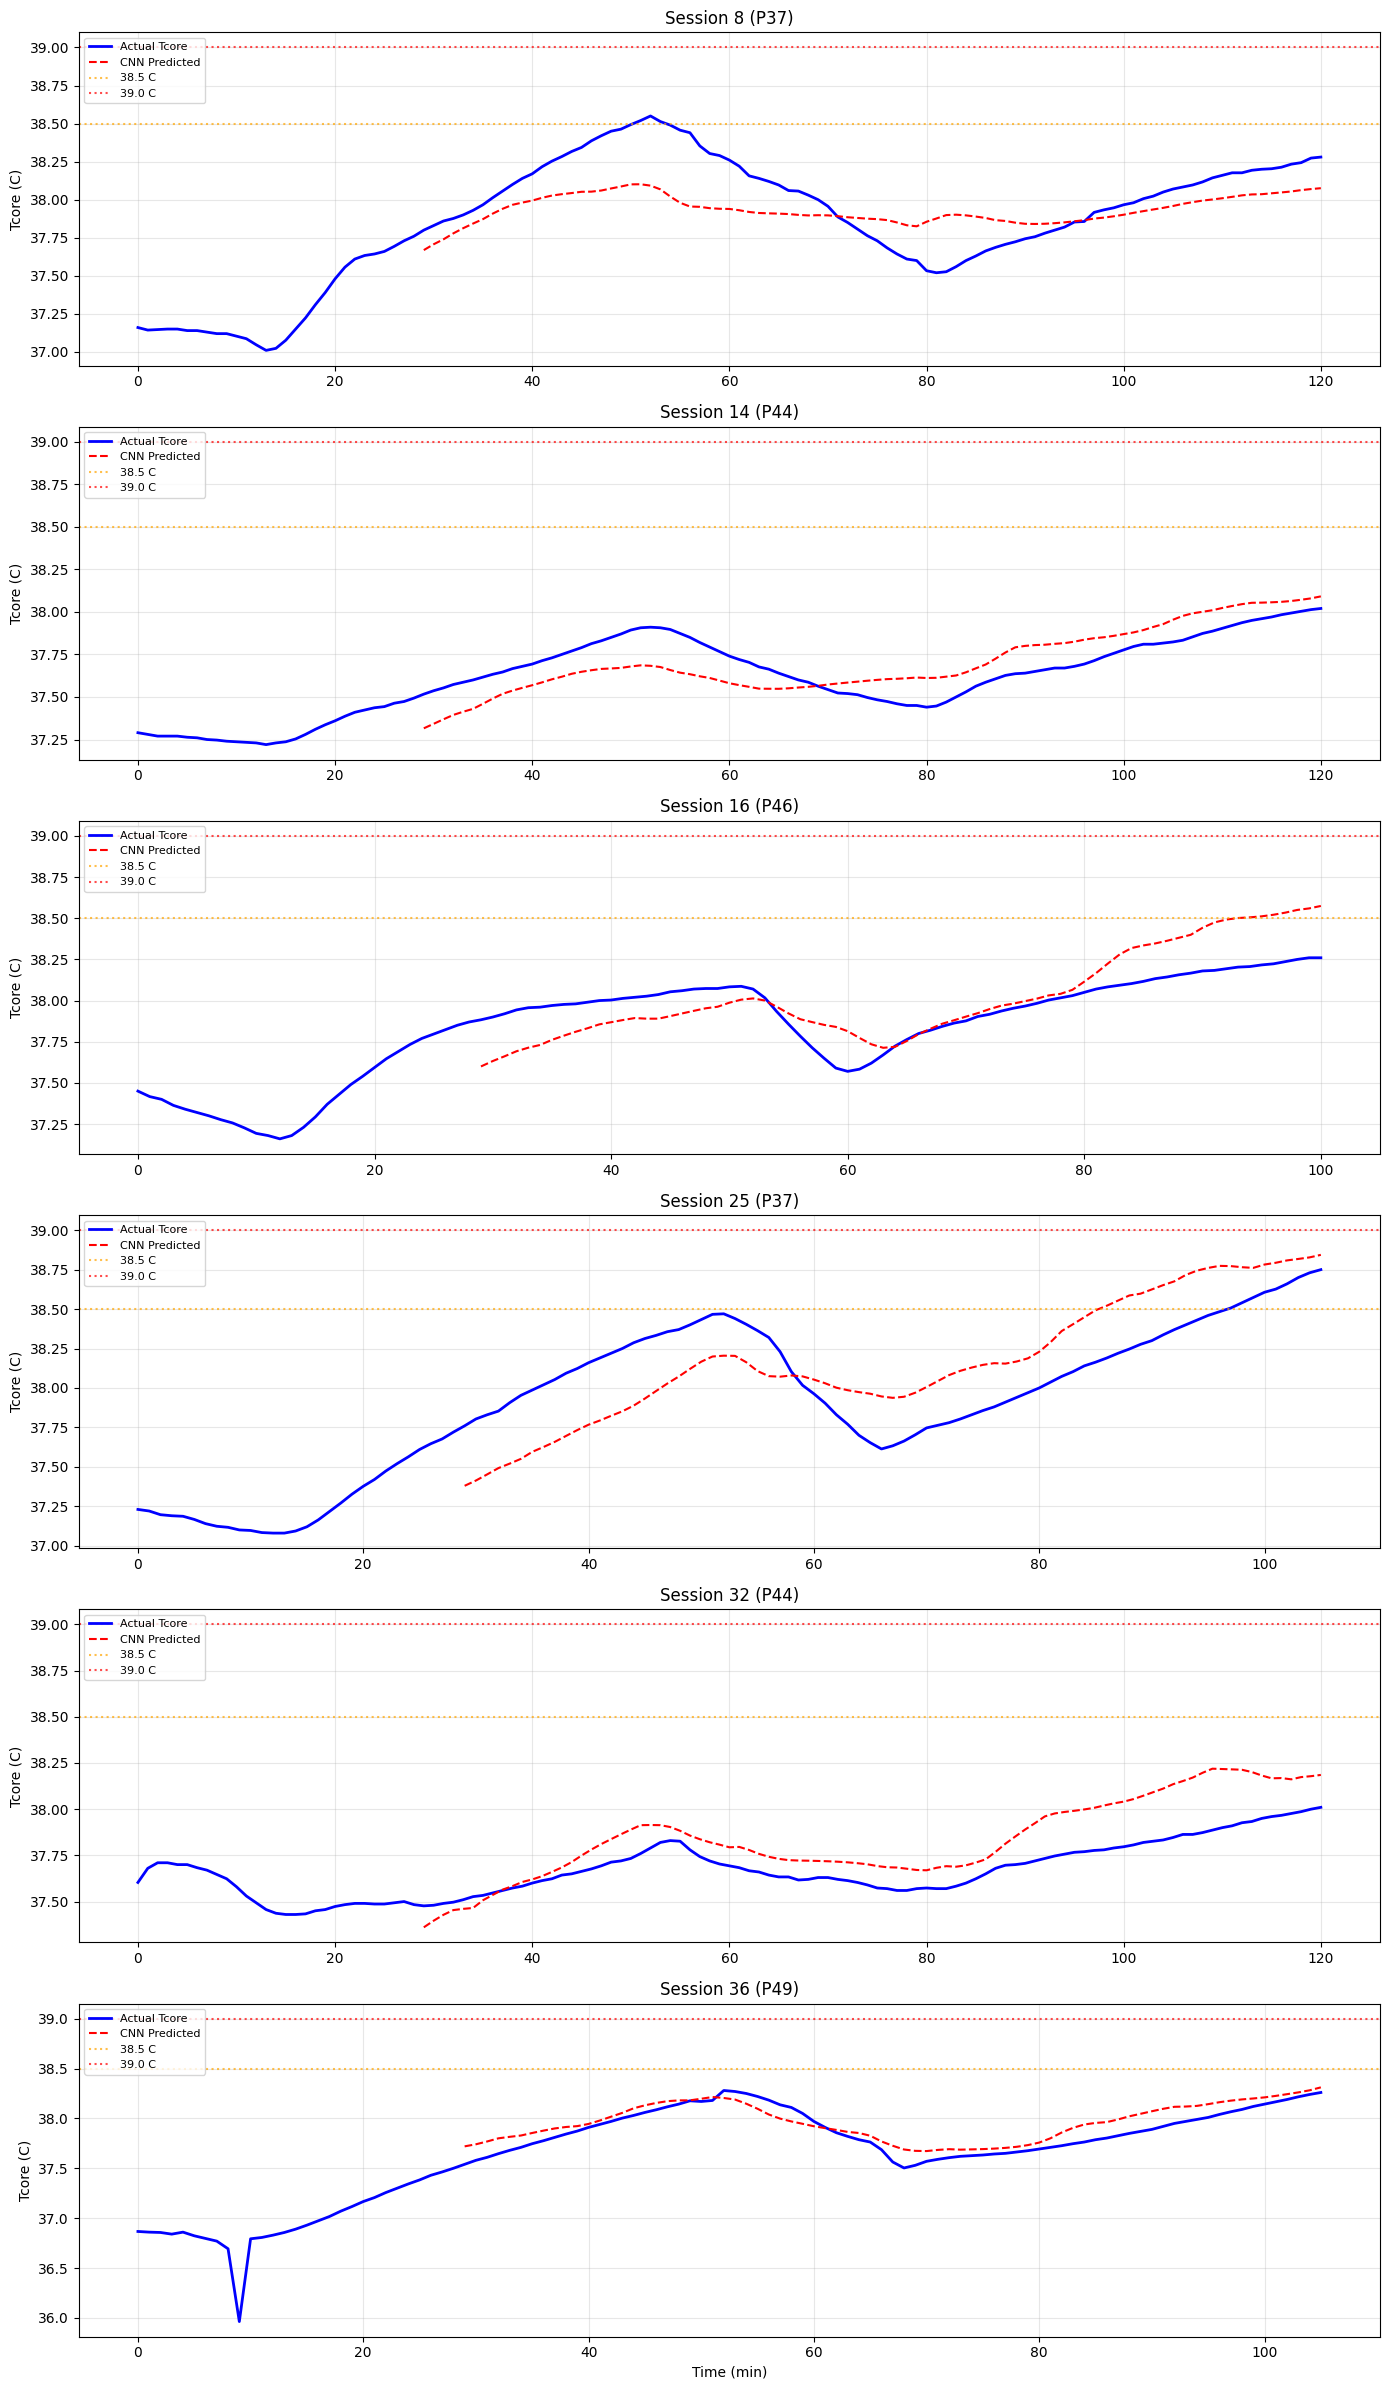

In [ ]:
# ============================================================
# SESSION TRAJECTORY PLOTS
# ============================================================

sessions = []
for sid, session in df_test.groupby('Session_ID'):
    session = session.sort_values('Time_Sec')
    if len(session) >= WINDOW_SIZE:
        sessions.append((sid, session))

n_plot = min(6, len(sessions))
if n_plot > 0:
    fig, axes = plt.subplots(n_plot, 1, figsize=(14, 4 * n_plot))
    if n_plot == 1: axes = [axes]
    for ax, (sid, session) in zip(axes, sessions[:n_plot]):
        dyn_vals = session[ALL_DYNAMIC].values.astype(np.float32)
        stat_vals = session[AVAILABLE_STATIC].iloc[0].values.astype(np.float32)
        targets = session[TARGET].values.astype(np.float32)
        time_min = (session['Time_Sec'].values - session['Time_Sec'].values[0]) / 60.0

        pred_times, pred_vals = [], []
        for i in range(0, len(session) - WINDOW_SIZE + 1, 1):
            xd = dyn_vals[i:i + WINDOW_SIZE][np.newaxis]
            xs = stat_vals[np.newaxis]
            p = model.predict([xd, xs], verbose=0).ravel()[0]
            pred_vals.append(p * y_std + y_mean)
            pred_times.append(time_min[i + WINDOW_SIZE - 1])

        pid = int(session['Participant'].iloc[0])
        ax.plot(time_min, targets, 'b-', linewidth=2, label='Actual Tcore')
        ax.plot(pred_times, pred_vals, 'r--', linewidth=1.5, label='CNN Predicted')
        ax.axhline(38.5, color='orange', linestyle=':', alpha=0.7, label='38.5 C')
        ax.axhline(39.0, color='red', linestyle=':', alpha=0.7, label='39.0 C')
        ax.set_ylabel('Tcore (C)')
        ax.set_title(f'Session {sid} (P{pid})')
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel('Time (min)')
    plt.tight_layout()
    plt.show()

## 11. TFLite Export & Size Analysis

In [ ]:
# ============================================================
# TFLITE EXPORT
# ============================================================

# Save Keras model
keras_path = os.path.join(MODEL_DIR, 'heatsense_cnn.keras')
model.save(keras_path)
print(f"Keras model saved: {keras_path}")

# --- Float32 TFLite ---
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
tflite_path = os.path.join(MODEL_DIR, 'heatsense_cnn.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
size_f32 = len(tflite_model) / 1024
print(f"\n  Float32 TFLite: {size_f32:.1f} KB")

# --- Dynamic-range quantized (weights INT8, activations float) ---
converter_dyn = tf.lite.TFLiteConverter.from_keras_model(model)
converter_dyn.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_dynq = converter_dyn.convert()
dynq_path = os.path.join(MODEL_DIR, 'heatsense_cnn_int8.tflite')
with open(dynq_path, 'wb') as f:
    f.write(tflite_dynq)
size_int8 = len(tflite_dynq) / 1024
print(f"  Dynamic-range INT8 TFLite: {size_int8:.1f} KB")

# --- Full INT8 quantization (representative dataset) ---
def representative_dataset():
    for i in range(min(200, len(X_tr_d))):
        yield [X_tr_d[i:i+1].astype(np.float32),
               X_tr_s[i:i+1].astype(np.float32)]

try:
    converter_full = tf.lite.TFLiteConverter.from_keras_model(model)
    converter_full.optimizations = [tf.lite.Optimize.DEFAULT]
    converter_full.representative_dataset = representative_dataset
    converter_full.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter_full.inference_input_type = tf.int8
    converter_full.inference_output_type = tf.int8
    tflite_fullint8 = converter_full.convert()
    fullint8_path = os.path.join(MODEL_DIR, 'heatsense_cnn_fullint8.tflite')
    with open(fullint8_path, 'wb') as f:
        f.write(tflite_fullint8)
    size_fullint8 = len(tflite_fullint8) / 1024
    print(f"  Full INT8 TFLite: {size_fullint8:.1f} KB")
except Exception as e:
    print(f"  Full INT8 quantization failed: {e}")
    print(f"  (Dynamic-range quantized model will be used for deployment)")

# --- Validate TFLite vs Keras ---
print(f"\n--- TFLite Validation ---")
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

dyn_idx = [d['index'] for d in input_details if len(d['shape']) == 3][0]
stat_idx = [d['index'] for d in input_details if len(d['shape']) == 2][0]

n_val = min(100, len(X_te_d))
keras_preds = model.predict([X_te_d[:n_val], X_te_s[:n_val]], verbose=0).ravel()
tflite_preds = []
for i in range(n_val):
    interpreter.set_tensor(dyn_idx, X_te_d[i:i+1])
    interpreter.set_tensor(stat_idx, X_te_s[i:i+1])
    interpreter.invoke()
    tflite_preds.append(interpreter.get_tensor(output_details[0]['index']).ravel()[0])

tflite_preds = np.array(tflite_preds)
mae_diff = np.mean(np.abs(keras_preds - tflite_preds)) * y_std
print(f"  Keras vs TFLite MAE diff: {mae_diff:.5f} C")
if mae_diff < 0.01:
    print(f"  PASS (< 0.01 C)")
else:
    print(f"  WARNING: significant conversion error!")

# ESP32-S3 deployment summary
print(f"\n--- ESP32-S3 Deployment Summary ---")
print(f"  Model size (float32): {size_f32:.1f} KB")
print(f"  Model size (int8):    {size_int8:.1f} KB")
print(f"  ESP32-S3 SRAM:        512 KB")
print(f"  PSRAM available:      8192 KB")
print(f"  Fits in SRAM:         {'YES' if size_int8 < 200 else 'TIGHT'}")

# Save target normalization
scaler_path = os.path.join(MODEL_DIR, 'scalers_cnn.pkl')
with open(scaler_path, 'rb') as f:
    scaler_data = pickle.load(f)
scaler_data['target_mean'] = float(y_mean)
scaler_data['target_std'] = float(y_std)
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler_data, f)
print(f"\n  Target normalization saved to {scaler_path}")

Keras model saved: /content/drive/MyDrive/HeatSense/output_cnn/models/heatsense_cnn.keras
Saved artifact at '/tmp/tmpejywgfd0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 30, 10), dtype=tf.float32, name='dynamic_input'), TensorSpec(shape=(None, 6), dtype=tf.float32, name='static_input')]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132795812441040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132795812442192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132795812443152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132795812442768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132795812442000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132795812441808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132795812444304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132795812443728: TensorSpec(shape=(), dtype=tf.resource, name=No

## 12. Comparison vs XGBoost Baseline

In [ ]:
# ============================================================
# COMPARISON: CNN vs XGBoost Baseline
# ============================================================

# XGBoost Phase 0 results (from notebook output)
xgb_mae = 0.2303
xgb_rmse = 0.2908
xgb_r2 = 0.4648
xgb_sens38 = 0.635
xgb_sens385 = 0.419
xgb_sens39 = 0.000  # Update if XGBoost detected any

# CNN V2 results (from old pipeline, no enriched features)
cnn_v2_mae = 0.2585
cnn_v2_r2 = 0.3547
cnn_v2_sens38 = 0.438
cnn_v2_sens385 = 0.167

def winner(a, b, higher_better=False):
    if higher_better:
        return 'CNN' if a > b else ('XGB' if b > a else 'TIE')
    else:
        return 'CNN' if a < b else ('XGB' if b < a else 'TIE')

print("=" * 75)
print("  MODEL COMPARISON: XGBoost vs 1D-CNN (enriched features)")
print("=" * 75)
print(f"{'Metric':<25} {'CNN V2 (old)':>12} {'XGBoost':>12} {'CNN (new)':>12} {'Winner':>8}")
print("-" * 75)
print(f"{'MAE (C)':<25} {cnn_v2_mae:>12.4f} {xgb_mae:>12.4f} {mae:>12.4f} {winner(mae, xgb_mae):>8}")
print(f"{'RMSE (C)':<25} {'N/A':>12} {xgb_rmse:>12.4f} {rmse:>12.4f} {winner(rmse, xgb_rmse):>8}")
print(f"{'R2':<25} {cnn_v2_r2:>12.4f} {xgb_r2:>12.4f} {r2:>12.4f} {winner(r2, xgb_r2, True):>8}")
print(f"{'Sens @ 38.0':<25} {cnn_v2_sens38:>12.3f} {xgb_sens38:>12.3f} {thresh_results[38.0]['sensitivity']:>12.3f} {winner(thresh_results[38.0]['sensitivity'], xgb_sens38, True):>8}")
print(f"{'Sens @ 38.5':<25} {cnn_v2_sens385:>12.3f} {xgb_sens385:>12.3f} {thresh_results[38.5]['sensitivity']:>12.3f} {winner(thresh_results[38.5]['sensitivity'], xgb_sens385, True):>8}")
print(f"{'Sens @ 39.0':<25} {'0.000':>12} {xgb_sens39:>12.3f} {thresh_results[39.0]['sensitivity']:>12.3f} {winner(thresh_results[39.0]['sensitivity'], xgb_sens39, True):>8}")
print(f"{'Bias (C)':<25} {'N/A':>12} {'N/A':>12} {mean_diff:>12.4f} {'':>8}")
print(f"{'Model size (INT8 KB)':<25} {'~45':>12} {'N/A':>12} {size_int8:>12.1f} {'':>8}")
print("-" * 75)
print(f"{'Enriched features?':<25} {'NO':>12} {'YES':>12} {'YES':>12}")
print(f"{'ESP32-S3 optimized?':<25} {'NO':>12} {'NO':>12} {'YES':>12}")
print(f"{'Deployable on-device?':<25} {'HARD':>12} {'NO':>12} {'YES':>12}")
print("=" * 75)

# Verdict
print(f"\n--- Verdict ---")
if mae < xgb_mae:
    print(f"  CNN WINS on MAE: {mae:.4f} vs {xgb_mae:.4f} (improvement: {(xgb_mae-mae)/xgb_mae*100:.1f}%)")
elif mae < xgb_mae * 1.05:
    print(f"  CNN COMPETITIVE: {mae:.4f} vs {xgb_mae:.4f} (within 5%)")
    print(f"  CNN preferred for deployment due to TFLite compatibility")
else:
    print(f"  XGBoost leads on MAE: {xgb_mae:.4f} vs {mae:.4f}")
    print(f"  Consider: hyperparameter tuning, more conv blocks, or hybrid approach")

  MODEL COMPARISON: XGBoost vs 1D-CNN (enriched features)
Metric                    CNN V2 (old)      XGBoost    CNN (new)   Winner
---------------------------------------------------------------------------
MAE (C)                         0.2585       0.2303       0.1783      CNN
RMSE (C)                           N/A       0.2908       0.2209      CNN
R2                              0.3547       0.4648       0.6911      CNN
Sens @ 38.0                      0.438        0.635        0.829      CNN
Sens @ 38.5                      0.167        0.419        0.512      CNN
Sens @ 39.0                      0.000        0.000        0.200      CNN
Bias (C)                           N/A          N/A      -0.0342         
Model size (INT8 KB)               ~45          N/A         23.8         
---------------------------------------------------------------------------
Enriched features?                  NO          YES          YES
ESP32-S3 optimized?                 NO           NO        

## 13. Summary & Next Steps

In [ ]:
# ============================================================
# SUMMARY
# ============================================================

print("=" * 60)
print("  PHASE 1 COMPLETE — 1D-CNN with Enriched Features")
print("=" * 60)

print(f"\n  Architecture:")
print(f"    Conv1D(32,k5) -> SepConv1D(48,k5) -> SepConv1D(64,k5)")
print(f"    + Residual skip + GlobalAvgPool + Static branch")
print(f"    Total params: {total_params:,}")

print(f"\n  Test Set Results:")
print(f"    MAE:  {mae:.4f} C")
print(f"    RMSE: {rmse:.4f} C")
print(f"    R2:   {r2:.4f}")
print(f"    Sensitivity @ 38.0: {thresh_results[38.0]['sensitivity']:.3f}")
print(f"    Sensitivity @ 38.5: {thresh_results[38.5]['sensitivity']:.3f}")
print(f"    Sensitivity @ 39.0: {thresh_results[39.0]['sensitivity']:.3f}")
print(f"    Bias: {mean_diff:.4f} C")

print(f"\n  Deployment:")
print(f"    INT8 model size: {size_int8:.1f} KB")
print(f"    TFLite validation error: {mae_diff:.5f} C")

print(f"\n  Next steps:")
print(f"    Phase 2: LSTM with same enriched features (compare temporal modeling)")
print(f"    Phase 3: Hybrid CNN-LSTM (CNN front-end + LSTM temporal aggregation)")
print(f"    Phase 4: Architecture selection based on accuracy + deployment cost")

print("\n" + "=" * 60)

  PHASE 1 COMPLETE — 1D-CNN with Enriched Features

  Architecture:
    Conv1D(32,k5) -> SepConv1D(48,k5) -> SepConv1D(64,k5)
    + Residual skip + GlobalAvgPool + Static branch
    Total params: 11,065

  Test Set Results:
    MAE:  0.1783 C
    RMSE: 0.2209 C
    R2:   0.6911
    Sensitivity @ 38.0: 0.829
    Sensitivity @ 38.5: 0.512
    Sensitivity @ 39.0: 0.200
    Bias: -0.0342 C

  Deployment:
    INT8 model size: 23.8 KB
    TFLite validation error: 0.00000 C

  Next steps:
    Phase 2: LSTM with same enriched features (compare temporal modeling)
    Phase 3: Hybrid CNN-LSTM (CNN front-end + LSTM temporal aggregation)
    Phase 4: Architecture selection based on accuracy + deployment cost

